   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4
total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64


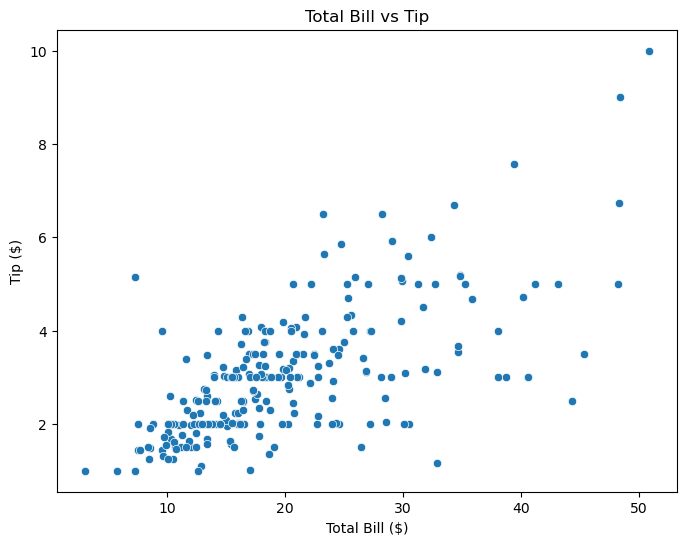

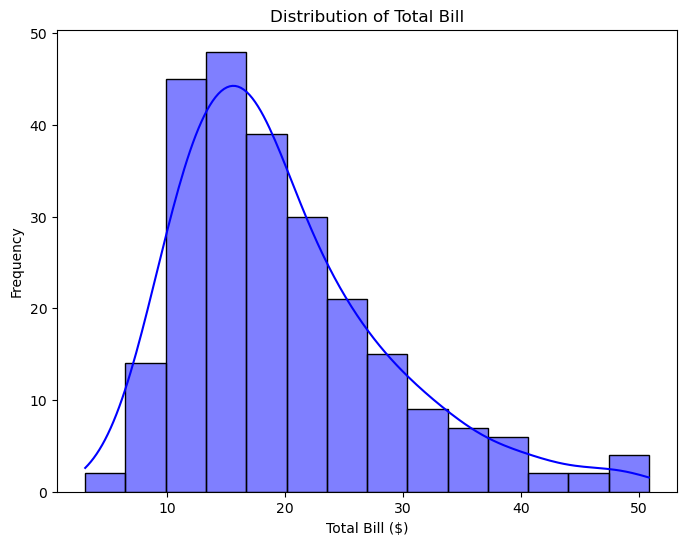

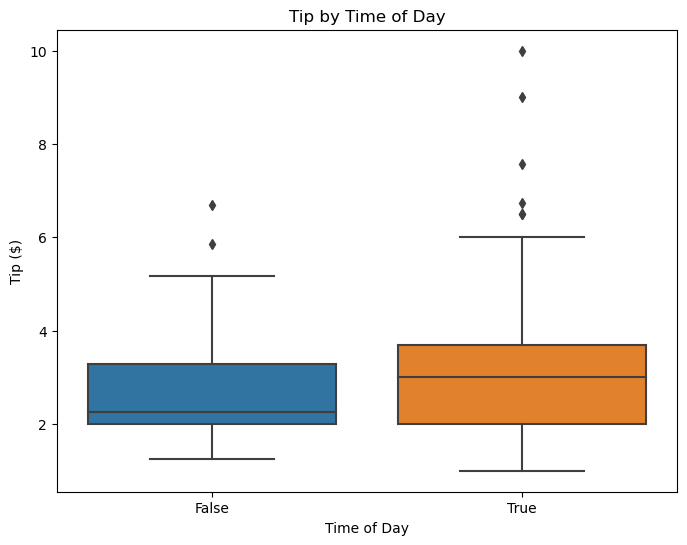

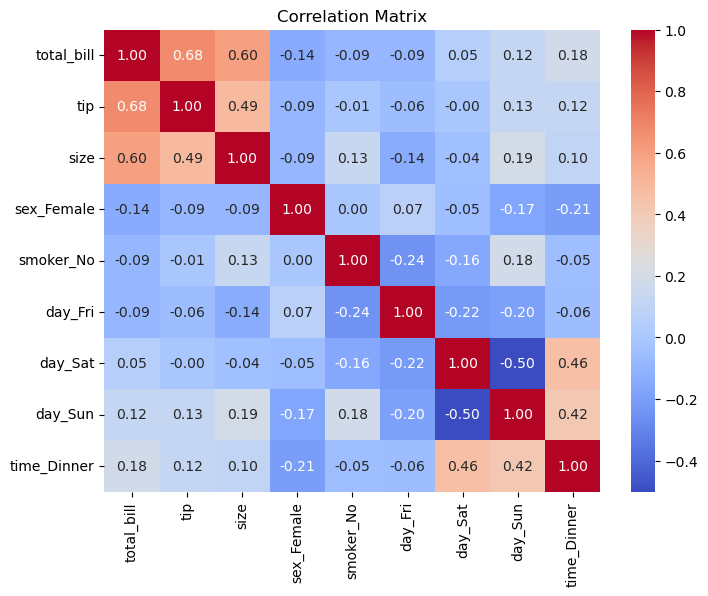

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
df = sns.load_dataset('tips')

# Display first few rows of the dataset
print(df.head())

# Check for missing values
print(df.isnull().sum())

# Basic preprocessing
# Convert categorical columns to numerical using get_dummies (one-hot encoding)
df = pd.get_dummies(df, columns=['sex', 'smoker', 'day', 'time'], drop_first=True)

# Visualize the relationship between total bill and tip using a scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x='total_bill', y='tip', data=df)
plt.title("Total Bill vs Tip")
plt.xlabel("Total Bill ($)")
plt.ylabel("Tip ($)")
plt.show()

# Visualize the distribution of total_bill
plt.figure(figsize=(8, 6))
sns.histplot(df['total_bill'], kde=True, color='blue')
plt.title("Distribution of Total Bill")
plt.xlabel("Total Bill ($)")
plt.ylabel("Frequency")
plt.show()

# Visualize the relationship between total_bill and tip for different times (Lunch vs Dinner)
plt.figure(figsize=(8, 6))
sns.boxplot(x='time_Dinner', y='tip', data=df)
plt.title("Tip by Time of Day")
plt.xlabel("Time of Day")
plt.ylabel("Tip ($)")
plt.show()

# Correlation heatmap
plt.figure(figsize=(8, 6))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix")
plt.show()


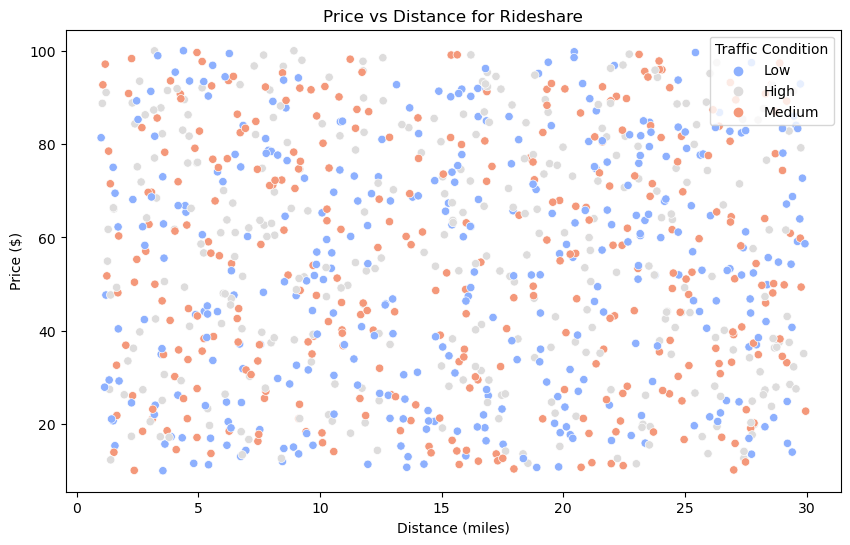

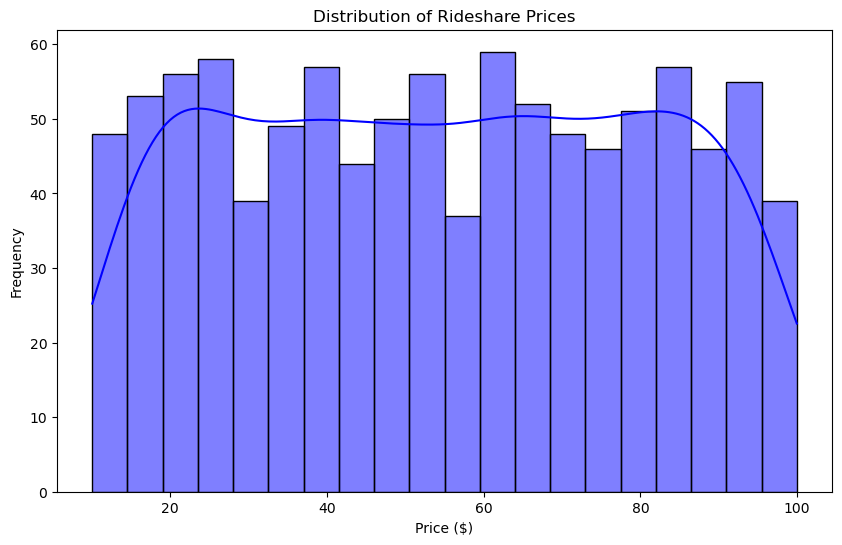

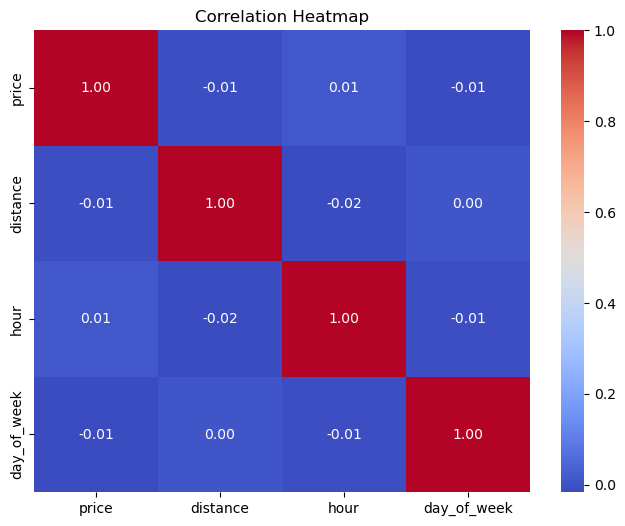

            Date/Time      price   distance  hour  day_of_week  \
0 2023-01-01 00:00:00  65.413061   4.489804     0            6   
1 2023-01-01 01:00:00  39.402226  12.998437     1            6   
2 2023-01-01 02:00:00  26.238384  17.466851     2            6   
3 2023-01-01 03:00:00  91.733074  15.827178     3            6   
4 2023-01-01 04:00:00  84.644298  23.550051     4            6   

   pickup_location_Suburbs  pickup_location_Uptown  dropoff_location_Suburbs  \
0                     True                   False                      True   
1                    False                    True                      True   
2                    False                    True                     False   
3                    False                   False                     False   
4                    False                   False                     False   

   dropoff_location_Uptown  traffic_condition_Low  traffic_condition_Medium  
0                    False                  

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Simulated example data
data = {
    'Date/Time': pd.date_range(start="2023-01-01", periods=1000, freq='H'),
    'pickup_location': np.random.choice(['Downtown', 'Uptown', 'Suburbs'], 1000),
    'dropoff_location': np.random.choice(['Downtown', 'Uptown', 'Suburbs'], 1000),
    'price': np.random.uniform(10, 100, 1000),  # random prices between 10 and 100
    'distance': np.random.uniform(1, 30, 1000),  # random distance in miles
    'traffic_condition': np.random.choice(['Low', 'Medium', 'High'], 1000)
}

# Load data into DataFrame
df = pd.DataFrame(data)

# Convert Date/Time to datetime object
df['Date/Time'] = pd.to_datetime(df['Date/Time'])

# Feature Engineering
df['hour'] = df['Date/Time'].dt.hour  # Extract hour from Date/Time for potential patterns
df['day_of_week'] = df['Date/Time'].dt.dayofweek  # Day of the week (0=Monday, 6=Sunday)

# Visualizing price vs distance
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='distance', y='price', hue='traffic_condition', palette='coolwarm')
plt.title('Price vs Distance for Rideshare')
plt.xlabel('Distance (miles)')
plt.ylabel('Price ($)')
plt.legend(title='Traffic Condition')
plt.show()

# Visualize price distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], kde=True, color='blue', bins=20)
plt.title('Distribution of Rideshare Prices')
plt.xlabel('Price ($)')
plt.ylabel('Frequency')
plt.show()

# Heatmap to show correlation between features
correlation_matrix = df[['price', 'distance', 'hour', 'day_of_week']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

# Encoding categorical variables for model input
df_encoded = pd.get_dummies(df, columns=['pickup_location', 'dropoff_location', 'traffic_condition'], drop_first=True)

# Sample of the processed dataset
print(df_encoded.head())
